<a href="https://colab.research.google.com/github/EmptyRain75/mnist-ai-classifier/blob/main/notebooks/SoftmaxPytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Softmax Regression with PyTorch

## Objective

The previous notebook implemented Softmax Regression manually with NumPy.

That required us to explicitly write:

- the linear transformation
- Softmax
- Cross Entropy
- gradient computation
- parameter updates
- mini-batch training

This notebook implements the **same model** using PyTorch.

The goal is not to introduce a new model.

The goal is to understand which parts PyTorch automates and how the NumPy implementation maps to PyTorch code.

The model is still:

$$ 784 \rightarrow 10 $$

with:

$$ Z = XW + b $$

followed by multiclass classification.

## NumPy vs PyTorch Overview

The NumPy implementation required us to manually write most parts of training.

| Task | NumPy | PyTorch |
|---|---|---|
| Parameters | create `W`, `b` manually | `nn.Linear` |
| Forward pass | `X @ W + b` | `model(X)` |
| Softmax + Cross Entropy | manual functions | `nn.CrossEntropyLoss()` |
| Gradients | manual derivation | `loss.backward()` |
| Parameter update | manual subtraction | `optimizer.step()` |
| Mini-batches | manual loops | `DataLoader` |

The mathematics is still the same.

PyTorch mainly automates the implementation.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## Module 1 — Loading MNIST

PyTorch provides utilities for loading datasets and creating mini-batches.

The MNIST images are converted to tensors and scaled automatically to the range:

$$ [0,1] $$

using `transforms.ToTensor()`.

`DataLoader` handles:

- batching
- shuffling
- iteration through the dataset

This replaces the manual mini-batch code from the NumPy implementation.

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])


Each batch contains 32 images.

PyTorch keeps MNIST images in image form:

`(batch, channel, height, width)`

so the shape is:

`(32, 1, 28, 28)`

Softmax Regression still expects 784 input features, so we will flatten each image before passing it to the linear layer.

## Module 2 — Define the Linear Model

In the NumPy implementation, we manually created:

$$ W \in \mathbb{R}^{784 \times 10} $$

and:

$$ b \in \mathbb{R}^{10} $$

then computed:

$$ Z = XW + b $$

PyTorch provides the same linear transformation through:

`nn.Linear(784, 10)`

This layer automatically creates and stores:

- the weight matrix
- the bias vector

The model still represents the same equation:

$$ Z = XW + b $$

PyTorch only manages the parameters for us.

In [ ]:
model = nn.Linear(784, 10)

print(model)

Linear(in_features=784, out_features=10, bias=True)


The layer contains 784 input features and 10 output classes.

Internally, PyTorch creates trainable parameters equivalent to the `W` and `b` from the NumPy implementation.

In [ ]:
print("Weight shape:", model.weight.shape)
print("Bias shape:", model.bias.shape)

Weight shape: torch.Size([10, 784])
Bias shape: torch.Size([10])


### Forward Pass

The MNIST batch currently has shape:

`(batch_size, 1, 28, 28)`

Before passing it into the linear layer, we flatten each image into:

`(batch_size, 784)`

Then:

`model(X)`

performs the linear transformation and returns the logits.

In [ ]:
images, labels = next(iter(train_loader))

images = images.view(images.size(0), -1)

logits = model(images)

print("Flattened images:", images.shape)
print("Logits:", logits.shape)

Flattened images: torch.Size([32, 784])
Logits: torch.Size([32, 10])


Each image now produces 10 logits.

These logits are the same type of values we manually computed in NumPy before applying Softmax.

## Module 3 — Loss and Optimizer

In the NumPy version, we manually implemented:

- Softmax
- Multiclass Cross Entropy
- gradients
- parameter updates

PyTorch provides built-in tools for these steps.

For classification, we use:

`nn.CrossEntropyLoss()`

Important:

`CrossEntropyLoss` expects **raw logits**.

We do not manually apply Softmax before passing the logits into the loss function.

PyTorch internally handles the numerically stable combination of Softmax-related computation and Cross Entropy.

In [ ]:
criterion = nn.CrossEntropyLoss()

For parameter updates, we use Stochastic Gradient Descent:

`torch.optim.SGD`

This replaces the manual update:

$$ W \leftarrow W - \eta dW $$

$$ b \leftarrow b - \eta db $$

The optimizer receives the model parameters and updates them after gradients have been computed.

In [ ]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

In [ ]:
logits = model(images)

loss = criterion(logits, labels)

print("Loss:", loss.item())

Loss: 2.3450515270233154


## Module 4 — Training Loop

The NumPy training loop manually performed:

1. forward pass
2. loss calculation
3. gradient calculation
4. parameter update

PyTorch keeps the same structure, but automates steps 3 and 4.

The key commands are:

`loss.backward()`

which computes the gradients automatically, and:

`optimizer.step()`

which updates the model parameters.

Before computing new gradients, we also call:

`optimizer.zero_grad()`

because PyTorch accumulates gradients by default.

In [ ]:
n_epochs = 5

for epoch in range(n_epochs):

    for images, labels in train_loader:

        # Flatten images
        images = images.view(images.size(0), -1)

        # Forward pass
        logits = model(images)

        # Loss
        loss = criterion(logits, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

    print(
        f"Epoch {epoch + 1}/{n_epochs} | "
        f"Loss: {loss.item():.4f}"
    )

Epoch 1/5 | Loss: 0.5241
Epoch 2/5 | Loss: 0.2734
Epoch 3/5 | Loss: 0.1033
Epoch 4/5 | Loss: 0.0986
Epoch 5/5 | Loss: 0.3300


### What PyTorch Automated

In the NumPy implementation, backpropagation required us to explicitly calculate:

$$ dZ = P - Y $$

$$ dW = \frac{1}{N}X^TdZ $$

$$ db = \frac{1}{N}\sum_i dZ_i $$

Then we manually updated the parameters.

In PyTorch:

`loss.backward()`

automatically computes the gradients of the loss with respect to every trainable parameter.

Then:

`optimizer.step()`

uses those gradients to update the parameters.

The mathematics is the same; PyTorch performs the derivative calculations and parameter management automatically.

## Module 5 — Evaluation

Evaluation follows the same idea as the NumPy version.

For each image:

1. compute logits
2. select the class with the largest logit
3. compare with the true label

Softmax is not required when we only want the predicted class.

This is because Softmax preserves the ordering of the logits:

$$ \arg\max_k z_k = \arg\max_k p_k $$

Therefore, we can apply `argmax` directly to the logits.

In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(images.size(0), -1)

        logits = model(images)

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9218


### Why `torch.no_grad()`?

During evaluation, we do not need gradients because the model parameters are not being updated.

`torch.no_grad()` tells PyTorch not to build the computation graph for gradient calculation.

This reduces memory usage and makes evaluation more efficient.

## Module 6 — NumPy vs PyTorch

The model itself did not change.

Both implementations still perform:

$$ X \rightarrow Z = XW+b \rightarrow \text{classification} $$

The difference is how much work is automated.

### NumPy

```text
Create W and b
↓
Compute logits manually
↓
Implement Softmax
↓
Implement Cross Entropy
↓
Derive gradients manually
↓
Update W and b manually
↓
Write mini-batch logic manually
```

### PyTorch

```text
nn.Linear
↓
CrossEntropyLoss
↓
loss.backward()
↓
optimizer.step()
↓
DataLoader
```
PyTorch therefore reduces the amount of manual code while keeping the same underlying mathematics.


## Module 7 — NumPy vs PyTorch Comparison

The NumPy implementation from the previous stage is uploaded directly into Colab as:

`softmax_regression.py`

This allows us to compare the completed manual implementation against the PyTorch implementation using the same dataset and training configuration.

The goal is to compare:

- training time
- validation accuracy
- test accuracy
- implementation complexity

The model architecture remains the same:

$$ 784 \rightarrow 10 $$

In [ ]:
from softmax_regression import (
    load_mnist,
    train_softmax_minibatch,
    predict,
    accuracy
)

### Shared Dataset for Fair Comparison

To compare NumPy and PyTorch fairly, both implementations must use the same:

- training samples
- validation samples
- test samples
- preprocessing
- labels

We therefore load the dataset once using the finalized NumPy implementation and reuse those exact arrays for both models.

In [ ]:
X_train_np, y_train_np, X_val_np, y_val_np, X_test_np, y_test_np = load_mnist(
    val_size=10000,
    seed=42
)

print("Train:", X_train_np.shape, y_train_np.shape)
print("Validation:", X_val_np.shape, y_val_np.shape)
print("Test:", X_test_np.shape, y_test_np.shape)

Train: (50000, 784) (50000,)
Validation: (10000, 784) (10000,)
Test: (10000, 784) (10000,)


### Convert the Same Data to PyTorch

The NumPy arrays are converted directly into PyTorch tensors.

No new split or preprocessing is performed.

This ensures that both implementations receive exactly the same input data.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_torch = torch.tensor(X_train_np, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_np, dtype=torch.long)

X_val_torch = torch.tensor(X_val_np, dtype=torch.float32)
y_val_torch = torch.tensor(y_val_np, dtype=torch.long)

X_test_torch = torch.tensor(X_test_np, dtype=torch.float32)
y_test_torch = torch.tensor(y_test_np, dtype=torch.long)

In [ ]:
batch_size = 32

train_dataset_compare = TensorDataset(
    X_train_torch,
    y_train_torch
)

generator = torch.Generator()
generator.manual_seed(42)

train_loader_compare = DataLoader(
    train_dataset_compare,
    batch_size=batch_size,
    shuffle=True,
    generator=generator
)

### NumPy Benchmark

The finalized NumPy implementation is trained using:

- learning rate = 0.1
- batch size = 32
- epochs = 50

These settings match the mini-batch configuration used in the previous Softmax experiments.

We record:

- training time
- validation accuracy
- test accuracy

In [ ]:
learning_rate = 0.1
batch_size = 32
n_epochs = 50

W_np, b_np, numpy_time = train_softmax_minibatch(
    X_train_np,
    y_train_np,
    n_classes=10,
    learning_rate=learning_rate,
    n_epochs=n_epochs,
    batch_size=batch_size,
    seed=42
)

numpy_val_pred = predict(
    X_val_np,
    W_np,
    b_np
)

numpy_test_pred = predict(
    X_test_np,
    W_np,
    b_np
)

numpy_val_acc = accuracy(
    y_val_np,
    numpy_val_pred
)

numpy_test_acc = accuracy(
    y_test_np,
    numpy_test_pred
)

print("NumPy training time      :", numpy_time)
print("NumPy validation accuracy:", numpy_val_acc)
print("NumPy test accuracy      :", numpy_test_acc)

NumPy training time      : 24.28381851499944
NumPy validation accuracy: 0.9205
NumPy test accuracy      : 0.9254


This gives us the reference result from the manual NumPy implementation.

The PyTorch model will now be trained on the same data with the same learning rate, batch size, and number of epochs.

In [ ]:
torch.manual_seed(42)

torch_model = nn.Linear(784, 10)

with torch.no_grad():
    torch_model.weight.zero_()
    torch_model.bias.zero_()

torch_criterion = nn.CrossEntropyLoss()

torch_optimizer = torch.optim.SGD(
    torch_model.parameters(),
    lr=learning_rate
)

In [ ]:
import time

start_time = time.perf_counter()

for epoch in range(n_epochs):

    for X_batch, y_batch in train_loader_compare:

        # Forward pass
        logits = torch_model(X_batch)

        # Loss
        loss = torch_criterion(
            logits,
            y_batch
        )

        # Clear old gradients
        torch_optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        torch_optimizer.step()

torch_time = time.perf_counter() - start_time

In [ ]:
with torch.no_grad():

    val_logits = torch_model(X_val_torch)
    val_pred = torch.argmax(
        val_logits,
        dim=1
    )

    test_logits = torch_model(X_test_torch)
    test_pred = torch.argmax(
        test_logits,
        dim=1
    )

torch_val_acc = (
    val_pred == y_val_torch
).float().mean().item()

torch_test_acc = (
    test_pred == y_test_torch
).float().mean().item()

print("PyTorch training time      :", torch_time)
print("PyTorch validation accuracy:", torch_val_acc)
print("PyTorch test accuracy      :", torch_test_acc)

PyTorch training time      : 67.79954144600015
PyTorch validation accuracy: 0.916700005531311
PyTorch test accuracy      : 0.9239000082015991


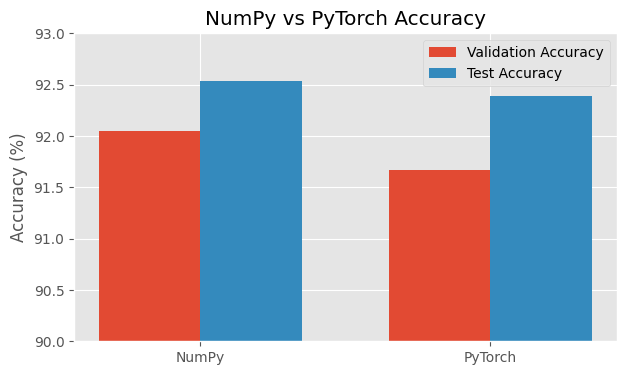

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

implementations = ["NumPy", "PyTorch"]

val_accuracies = [
    numpy_val_acc * 100,
    torch_val_acc * 100
]

test_accuracies = [
    numpy_test_acc * 100,
    torch_test_acc * 100
]

x = np.arange(len(implementations))
width = 0.35

plt.figure(figsize=(7, 4))

plt.bar(
    x - width / 2,
    val_accuracies,
    width,
    label="Validation Accuracy"
)

plt.bar(
    x + width / 2,
    test_accuracies,
    width,
    label="Test Accuracy"
)

plt.xticks(x, implementations)
plt.ylabel("Accuracy (%)")
plt.title("NumPy vs PyTorch Accuracy")
plt.ylim(90, 93)
plt.legend()

plt.show()

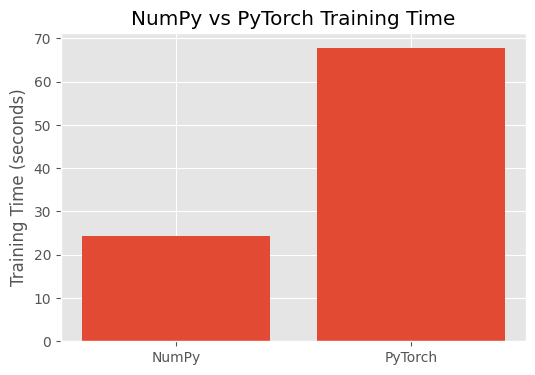

In [ ]:
training_times = [
    numpy_time,
    torch_time
]

plt.figure(figsize=(6, 4))

plt.bar(
    implementations,
    training_times
)

plt.ylabel("Training Time (seconds)")
plt.title("NumPy vs PyTorch Training Time")

plt.show()

### Analysis

The NumPy and PyTorch implementations achieve almost identical classification performance.

The test accuracy difference is only:

$$ 92.54\% - 92.39\% = 0.15\% $$

This confirms that PyTorch does not make the Softmax Regression model inherently more powerful.

Both implementations represent the same linear classifier.

However, NumPy is significantly faster in this experiment.

The NumPy implementation takes about 24 seconds, while PyTorch takes about 68 seconds.

For this simple model, the actual computation is small, so PyTorch's additional framework overhead becomes noticeable.

PyTorch performs extra work related to:

- automatic differentiation
- gradient storage
- computation graph management
- optimizer handling
- tensor abstraction
- DataLoader iteration

The NumPy version directly executes the required matrix operations and manually computed gradients, so it has less overhead.

Therefore, for a very small linear model on CPU, NumPy can be faster.

The advantage of PyTorch is not raw speed in this specific case, but automation, scalability, GPU support, and easier implementation of more complex models such as MLPs, CNNs, and Transformers.

## Conclusion

This notebook reimplemented the same Softmax Regression classifier using PyTorch after first building it manually with NumPy.

The model itself did not fundamentally change:

```text
Input
  ↓
Flatten
  ↓
Linear Layer
  ↓
Logits
  ↓
Cross Entropy
  ↓
Prediction
```

The main difference is that PyTorch automates many operations that were implemented manually in the NumPy version.

In the NumPy implementation, we explicitly wrote:

- Softmax
- Cross Entropy
- Gradient computation
- Parameter updates
- Mini-batch training logic

In the PyTorch implementation, these responsibilities were largely handled by:

- `nn.Linear`
- `nn.CrossEntropyLoss`
- Autograd through `loss.backward()`
- `torch.optim.SGD`
- `DataLoader`

The fair comparison showed that both implementations achieved similar accuracy on MNIST, which is expected because both represent the same linear classifier.

The PyTorch version was not necessarily faster in this experiment. Training time depends on implementation details, hardware, framework overhead, data loading, and matrix-operation efficiency, so PyTorch should not automatically be assumed to outperform a simple NumPy implementation for a small model.

The main advantage of PyTorch becomes more important as the architecture grows more complex. Instead of manually deriving and implementing every gradient, PyTorch allows the model to be constructed from reusable layers while automatically computing gradients during backpropagation.

Therefore, this stage serves as the transition from manually implementing machine-learning mathematics to using a deep-learning framework.

The next stage will extend Softmax Regression into a **Multilayer Perceptron (MLP)** by introducing hidden layers and nonlinear activation functions.

```text
Softmax Regression
Linear
  ↓
10 logits


Becomes


MLP
Linear
  ↓
Activation
  ↓
Linear
  ↓
10 logits
```

This change allows the model to learn nonlinear representations instead of relying only on a linear decision boundary.